<a href="https://colab.research.google.com/github/clobos/ECO5056_2026/blob/main/Aula_01_Introducao_Machine_Learning_Ecologia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 01 — Introdução ao Machine Learning em Ecologia
**Base real:** Palmer Penguins. **Pergunta:** a morfologia permite classificar espécies de pinguins sem usar a ilha como atalho?

Este notebook foi projetado para Google Colab. A cópia local é usada somente como fallback de QA quando o ambiente de execução não tem acesso à internet.

## 1. Objetivos da aula
- Distinguir IA, Machine Learning e Deep Learning.
- Reconhecer *features* e *target*.
- Executar um primeiro fluxo supervisionado de classificação.
- Separar treinamento e teste antes de ajustar o pré-processamento.
- Interpretar métricas sem confundir predição com causalidade.

## 2. Pergunta ecológica
**Podemos predizer a espécie de um pinguim a partir de quatro medidas morfológicas?**

A ilha não será usada como preditora: ela é fortemente associada à espécie nesta amostra e poderia transformar o modelo em um atalho de localização, reduzindo o valor pedagógico da generalização morfológica.

## 3. Fonte dos dados
Horst, Hill & Gorman (2020), *palmerpenguins*, DOI 10.5281/zenodo.3960218, licença CC0. Dados originalmente coletados no Palmer Station Antarctica LTER; referência ecológica: Gorman, Williams & Fraser (2014), PLOS ONE, DOI 10.1371/journal.pone.0090081.

URL: https://allisonhorst.github.io/palmerpenguins/

## 4. Importação das bibliotecas

In [1]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
np.random.seed(42)
print("Python:", sys.version.split()[0], "| pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)

Python: 3.12.13 | pandas: 2.2.2 | scikit-learn: 1.6.1


## 5. Download ou carregamento dos dados

In [2]:
URL = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
try:
    dados = pd.read_csv(URL)
    fonte_execucao = "URL pública"
except Exception:
    fallback = Path("/mnt/data/penguins.csv")
    if not fallback.exists():
        raise
    dados = pd.read_csv(fallback)
    fonte_execucao = "fallback local de QA"
print(fonte_execucao, dados.shape)

URL pública (344, 8)


## 6. Conhecendo a base

In [3]:
display(dados.head())
print(dados["species"].value_counts())
print("Ausentes por variável:")
print(dados.isna().sum())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
Ausentes por variável:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


## 7. Análise exploratória

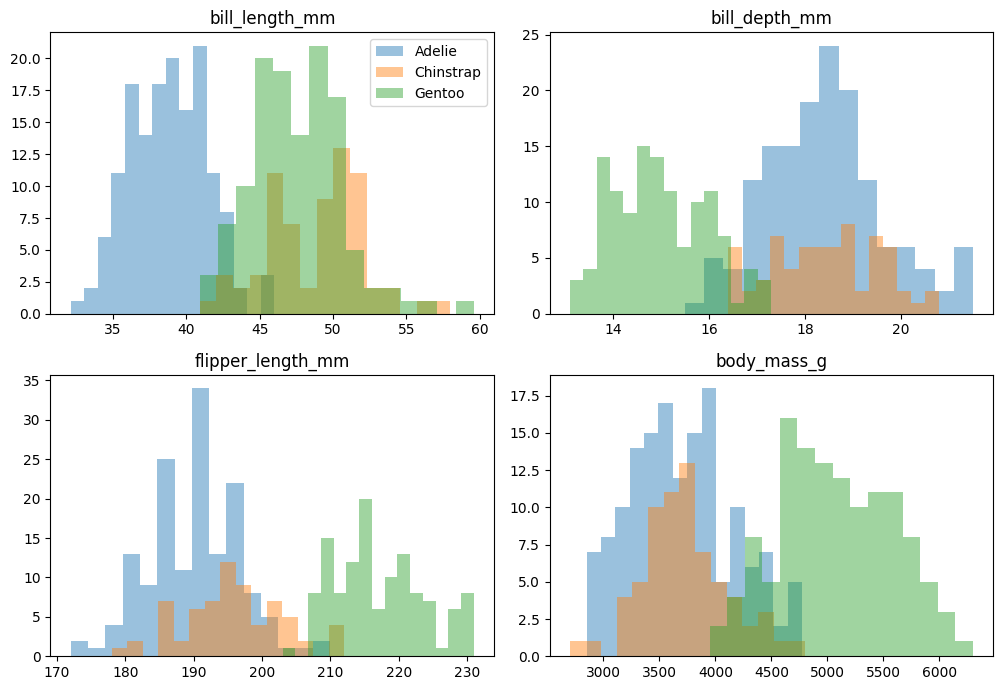

In [4]:
features = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]
fig, axes = plt.subplots(2,2,figsize=(10,7))
for ax,var in zip(axes.ravel(),features):
    for sp,sub in dados.groupby("species"):
        ax.hist(sub[var].dropna(), bins=15, alpha=.45, label=sp)
    ax.set_title(var)
axes[0,0].legend()
plt.tight_layout(); plt.show()

## 8. Preparação dos dados
Duas linhas têm medidas morfológicas ausentes; para esta introdução, removemos apenas essas linhas. Em estudos reais, a decisão sobre imputação deve ser pré-especificada e ajustada apenas no conjunto de treinamento.

In [5]:
analise = dados.dropna(subset=features+["species"]).copy()
X = analise[features]
y = analise["species"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.25,stratify=y,random_state=42)
print("n total analítico:",len(analise),"| treino:",len(X_train),"| teste:",len(X_test))

n total analítico: 342 | treino: 256 | teste: 86


## 9. Construção do modelo
A regressão logística multinomial funciona como *baseline* e ponte entre Estatística e ML. A padronização fica dentro de `Pipeline`, evitando vazamento de informação.

In [6]:
modelo = Pipeline([
    ("scale", StandardScaler()),
    ("logit", LogisticRegression(max_iter=3000, random_state=42))
])
modelo.fit(X_train,y_train)
pred = modelo.predict(X_test)

## 10. Avaliação

In [7]:
metricas = {
 "accuracy": accuracy_score(y_test,pred),
 "balanced_accuracy": balanced_accuracy_score(y_test,pred),
 "f1_macro": f1_score(y_test,pred,average="macro")
}
print(metricas)
print(classification_report(y_test,pred))

{'accuracy': 1.0, 'balanced_accuracy': np.float64(1.0), 'f1_macro': 1.0}
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        38
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86



## 11. Visualizações

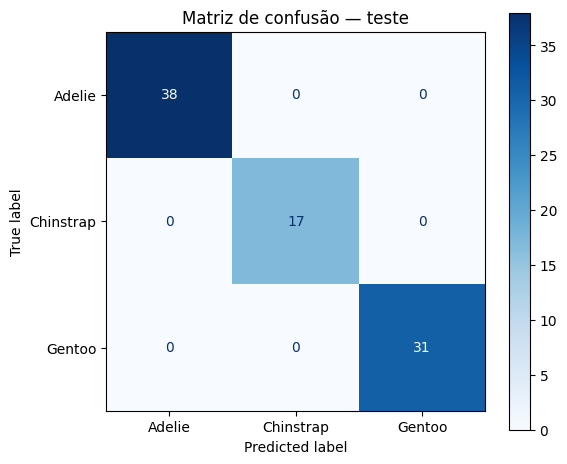

In [8]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test,pred,ax=ax,cmap="Blues")
ax.set_title("Matriz de confusão — teste")
plt.tight_layout(); plt.show()

## 12. Interpretação ecológica
Desempenho muito alto neste conjunto significa que as três espécies estão fortemente separadas pelas quatro medidas morfológicas **nesta amostra**. Isso não demonstra causalidade, não garante transferência para outras populações/anos e não substitui validação externa.

## 13. Limitações
- Amostragem restrita ao arquipélago Palmer e a anos específicos.
- Indivíduos podem compartilhar contexto espacial/temporal.
- A espécie é muito separável morfologicamente; o problema é didaticamente “fácil”.
- Sexo e ilha foram deliberadamente omitidos.
- Acurácia de teste não estima necessariamente desempenho sob *domain shift*.

## 14. Exercícios
1. Inclua `sex` usando imputação/codificação dentro de um `ColumnTransformer`. O desempenho muda?
2. Compare uma divisão aleatória com uma estratégia que deixa uma ilha fora. Essa validação é cientificamente compatível com a pergunta?
3. Explique por que usar `island` pode ser considerado um atalho, mas não necessariamente *data leakage* formal.
4. Troque a resposta para uma variável contínua e formule um problema de regressão.

## 15. Desafio para o estudante
Escreva, em no máximo 200 palavras, um plano de validação para aplicar o classificador a uma nova campanha antártica cinco anos depois. Identifique ao menos três formas de *domain shift*.
### Reprodutibilidade
Todos os procedimentos aleatórios usam semente 42. Ao adaptar o notebook, mantenha a separação entre dados de desenvolvimento e dados de avaliação e registre versões de bibliotecas e decisões analíticas.